# Descripción y Limpieza de Datos

**Proyecto 2. Análisis Exploratorio | LMSYS Chatbot Arena | CC3084 Data Science**

Acá se describe cada variable del archivo crudo, se miden los problemas de calidad que trae
(duplicados, texto serializado, turnos sin respuesta) y se genera el dataset limpio
`data/processed/train_clean.csv`, que es el que usa el análisis exploratorio.

---
## 1. Configuración del Ambiente

In [1]:
import sys
import json
from pathlib import Path

# Agregar el directorio raíz al path para importar src/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as cfg
from src import load

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

FIGURAS = ROOT / 'docs' / 'figures'
FIGURAS.mkdir(parents=True, exist_ok=True)

print('Ambiente configurado correctamente.')

Ambiente configurado correctamente.


In [2]:
df = load.load_train()
n_original = len(df)
print(f'Shape de train.csv: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)

Shape de train.csv: 57,477 filas x 9 columnas


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


---
## 2. Descripción de Variables

Cada fila del dataset es una **batalla**: un usuario emite uno o más turnos de conversación
(`prompt`), recibe respuestas de dos modelos anónimos (`response_a`, `response_b`) y elige cuál
prefiere. El resultado no está en una sola columna, sino repartido en tres columnas binarias
mutuamente excluyentes (`winner_model_a`, `winner_model_b`, `winner_tie`), de las cuales
exactamente una vale 1 por fila.

In [3]:
descripcion_vars = pd.DataFrame([
    {'columna': 'id',             'tipo': 'identificador',     'descripcion': 'Identificador único de la batalla',                        'rango_cardinalidad': f'{df[cfg.COL_ID].nunique():,} valores únicos'},
    {'columna': 'model_a',        'tipo': 'categórica',        'descripcion': 'Nombre del modelo en la posición A',                       'rango_cardinalidad': f'{df[cfg.COL_MODEL_A].nunique()} modelos distintos'},
    {'columna': 'model_b',        'tipo': 'categórica',        'descripcion': 'Nombre del modelo en la posición B',                       'rango_cardinalidad': f'{df[cfg.COL_MODEL_B].nunique()} modelos distintos'},
    {'columna': 'prompt',         'tipo': 'texto (JSON list)', 'descripcion': 'Turnos de conversación emitidos por el usuario',           'rango_cardinalidad': 'Lista de strings serializada como JSON'},
    {'columna': 'response_a',     'tipo': 'texto (JSON list)', 'descripcion': 'Respuestas del modelo A, un elemento por turno',           'rango_cardinalidad': 'Lista de strings serializada como JSON, puede contener null'},
    {'columna': 'response_b',     'tipo': 'texto (JSON list)', 'descripcion': 'Respuestas del modelo B, un elemento por turno',           'rango_cardinalidad': 'Lista de strings serializada como JSON, puede contener null'},
    {'columna': 'winner_model_a', 'tipo': 'binaria (0/1)',     'descripcion': '1 si el usuario prefirió la respuesta del modelo A',       'rango_cardinalidad': '{0, 1}'},
    {'columna': 'winner_model_b', 'tipo': 'binaria (0/1)',     'descripcion': '1 si el usuario prefirió la respuesta del modelo B',       'rango_cardinalidad': '{0, 1}'},
    {'columna': 'winner_tie',     'tipo': 'binaria (0/1)',     'descripcion': '1 si el usuario declaró un empate entre ambas respuestas', 'rango_cardinalidad': '{0, 1}'},
])
descripcion_vars

,columna,tipo,descripcion,rango_cardinalidad
0,id,identificador,Identificador único de la batalla,"57,477 valores únicos"
1,model_a,categórica,Nombre del modelo en la posición A,64 modelos distintos
2,model_b,categórica,Nombre del modelo en la posición B,64 modelos distintos
3,prompt,texto (JSON list),Turnos de conversación emitidos por el usuario,Lista de strings serializada como JSON
4,response_a,texto (JSON list),"Respuestas del modelo A, un elemento por turno","Lista de strings serializada como JSON, puede ..."
5,response_b,texto (JSON list),"Respuestas del modelo B, un elemento por turno","Lista de strings serializada como JSON, puede ..."
6,winner_model_a,binaria (0/1),1 si el usuario prefirió la respuesta del mode...,"{0, 1}"
7,winner_model_b,binaria (0/1),1 si el usuario prefirió la respuesta del mode...,"{0, 1}"
8,winner_tie,binaria (0/1),1 si el usuario declaró un empate entre ambas ...,"{0, 1}"


---
## 3. Duplicados

Se revisan dos criterios. El primero es el `id`, que debería ser único. El segundo es el **contenido
de la batalla**: dos filas con el mismo `prompt` y las mismas dos respuestas describen el mismo
enfrentamiento aunque lleven `id` distinto, y contarlas dos veces le daría un peso inflado a los
modelos involucrados. Para comparar textos largos sin agrupar por las columnas completas se usa un
hash por fila.

In [4]:
hash_batalla = pd.util.hash_pandas_object(df[cfg.TEXT_COLS], index=False)
voto = pd.Series(df[cfg.WINNER_COLS].to_numpy().argmax(axis=1), index=df.index)

dup_id = df.duplicated(subset=cfg.COL_ID).sum()
dup_contenido = hash_batalla.duplicated().sum()

print(f'Filas con id duplicado:        {dup_id:,}')
print(f'Filas con contenido duplicado: {dup_contenido:,}')

if dup_contenido:
    repetidas = hash_batalla.duplicated(keep=False)
    grupos = voto[repetidas].groupby(hash_batalla[repetidas]).nunique()
    print(f'  Grupos de batallas repetidas:                 {len(grupos):,}')
    print(f'  De ellos, con votos contradictorios entre sí: {grupos.gt(1).sum():,}')

Filas con id duplicado:        0
Filas con contenido duplicado: 71
  Grupos de batallas repetidas:                 29
  De ellos, con votos contradictorios entre sí: 4


In [5]:
df = df[~df.duplicated(subset=cfg.COL_ID) & ~hash_batalla.duplicated()].reset_index(drop=True)
print(f'Filas eliminadas por duplicidad: {n_original - len(df):,}')
print(f'Filas restantes:                 {len(df):,}')

Filas eliminadas por duplicidad: 71
Filas restantes:                 57,406


---
## 4. Parseo de las Columnas JSON

`prompt`, `response_a` y `response_b` no son texto plano sino *strings* que contienen una lista JSON
con un elemento por turno de conversación. Hay que deserializarlos para poder medir longitudes y
contar turnos.

Dos detalles del parseo importan bastante:

- Se usa `json.loads(..., strict=False)` porque varias respuestas traen saltos de línea y caracteres
  de control sin escapar que el modo estricto rechaza.
- Cuando aun así el string no se puede parsear, la función devuelve `None` y no una lista vacía. La
  diferencia no es menor: una lista vacía terminaría convertida en una longitud de 0 caracteres, un
  dato inventado que se colaría en los histogramas y las medias del análisis. Devolviendo `None` se
  pueden contar y decidir qué hacer con ellas.

In [6]:
def cargar_turnos(texto_json):
    """Deserializa el JSON de turnos. Devuelve None si el string no es parseable."""
    try:
        turnos = json.loads(texto_json, strict=False)
    except (json.JSONDecodeError, TypeError):
        return None
    if turnos is None:
        return []
    return turnos if isinstance(turnos, list) else [turnos]


def unir_turnos(turnos):
    """Une los turnos en un solo texto plano; un turno sin respuesta aporta cadena vacía."""
    return '\n'.join('' if t is None else str(t) for t in turnos).strip()


COLS_TEXTO = {cfg.COL_PROMPT: 'prompt', cfg.COL_RESP_A: 'resp_a', cfg.COL_RESP_B: 'resp_b'}

fallos, turnos_nulos = {}, {}
for col, destino in COLS_TEXTO.items():
    turnos = df[col].apply(cargar_turnos)
    fallos[destino] = turnos.isna()
    turnos_nulos[destino] = turnos.map(lambda ts: sum(t is None for t in ts) if isinstance(ts, list) else 0)
    df[f'{destino}_text'] = turnos.map(lambda ts: unir_turnos(ts) if isinstance(ts, list) else '')
    df[f'n_turnos_{destino}'] = turnos.map(lambda ts: len(ts) if isinstance(ts, list) else 0)
    del turnos

fallos = pd.DataFrame(fallos)
turnos_nulos = pd.DataFrame(turnos_nulos)

pd.DataFrame({
    'filas no parseables': fallos.sum(),
    '% del total': (fallos.mean() * 100).round(3),
})

,filas no parseables,% del total
prompt,0,0.0
resp_a,0,0.0
resp_b,0,0.0


In [7]:
filas_rotas = fallos.any(axis=1)
print(f'Filas con al menos una columna JSON no parseable: {filas_rotas.sum():,} '
      f'({filas_rotas.mean() * 100:.3f}% del total)')

df = df.loc[~filas_rotas].reset_index(drop=True)
turnos_nulos = turnos_nulos.loc[~filas_rotas].reset_index(drop=True)
print(f'Filas restantes tras descartarlas:                {len(df):,}')

Filas con al menos una columna JSON no parseable: 0 (0.000% del total)
Filas restantes tras descartarlas:                57,406


**Decisión sobre las filas no parseables:** se descartan. Su texto no se puede recuperar y dejarlas
obligaría a darles una longitud de 0 que no corresponde a nada real. Son una fracción mínima del
dataset, así que sacarlas no cambia la representatividad de la muestra y evita que todas las
estadísticas de longitud queden tiradas hacia abajo.

Con las tres columnas ya parseadas se puede revisar su consistencia: en una batalla bien formada, el
número de turnos del prompt tendría que coincidir con el número de respuestas de cada modelo.

In [8]:
cols_turnos = ['n_turnos_prompt', 'n_turnos_resp_a', 'n_turnos_resp_b']
inconsistentes = df[cols_turnos].nunique(axis=1) > 1

print(f'Batallas donde prompt y respuestas no tienen el mismo número de turnos: '
      f'{inconsistentes.sum():,} ({inconsistentes.mean() * 100:.3f}%)')
print()
print('Distribución del número de turnos por batalla:')
print(df['n_turnos_prompt'].value_counts().sort_index().to_string())

Batallas donde prompt y respuestas no tienen el mismo número de turnos: 0 (0.000%)

Distribución del número de turnos por batalla:
n_turnos_prompt
1     49868
2      4672
3      1485
4       607
5       311
6       167
7       103
8        60
9        44
10       29
11       16
12       14
13        5
14        3
15        4
16        2
17        3
18        1
19        4
20        2
21        1
22        1
29        1
32        1
35        1
36        1


---
## 5. Valores Nulos y Turnos sin Respuesta

La ausencia de datos aparece en dos niveles y hay que medirlos por separado:

- **A nivel de celda:** una columna vacía en una fila.
- **A nivel de turno:** un `null` dentro de la lista JSON, o sea un turno que ese modelo no respondió.
  Un `isnull()` sobre el dataframe crudo no lo ve, porque la celda contiene un string JSON
  perfectamente válido.

In [9]:
resumen_nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    '% nulos': (df.isnull().mean() * 100).round(3),
})
print(f'Total de valores nulos a nivel de celda: {resumen_nulos["nulos"].sum():,}')
resumen_nulos

Total de valores nulos a nivel de celda: 0


,nulos,% nulos
id,0,0.0
model_a,0,0.0
model_b,0,0.0
prompt,0,0.0
response_a,0,0.0
response_b,0,0.0
winner_model_a,0,0.0
winner_model_b,0,0.0
winner_tie,0,0.0
prompt_text,0,0.0


In [10]:
resumen_turnos = pd.DataFrame({
    'turnos sin respuesta': turnos_nulos.sum(),
    'filas afectadas': (turnos_nulos > 0).sum(),
    '% de filas': ((turnos_nulos > 0).mean() * 100).round(3),
})
resumen_turnos

,turnos sin respuesta,filas afectadas,% de filas
prompt,0,0,0.000
resp_a,120,111,0.193
resp_b,126,120,0.209


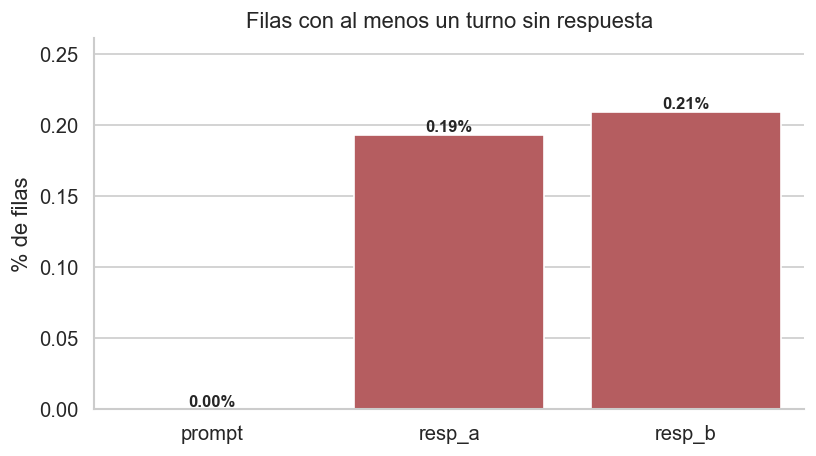

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=resumen_turnos.index, y=resumen_turnos['% de filas'], color='#C44E52', ax=ax)

for i, v in enumerate(resumen_turnos['% de filas']):
    ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Filas con al menos un turno sin respuesta')
ax.set_ylabel('% de filas')
ax.set_xlabel('')
ax.set_ylim(0, max(resumen_turnos['% de filas'].max() * 1.25, 0.1))
sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_turnos_sin_respuesta.png', dpi=150, bbox_inches='tight')
plt.show()

**Decisión sobre los turnos sin respuesta:** no se elimina la fila. Un turno vacío dentro de una
conversación de varios turnos sigue siendo parte de una batalla válida, con su voto y su par de
modelos, y el usuario votó viendo exactamente ese contenido. Al unir los turnos, el que falta aporta
una cadena vacía, así que la longitud final refleja lo que el modelo realmente entregó. El caso
extremo, una respuesta enteramente vacía, queda con longitud 0 y se revisa como valor atípico más
adelante.

---
## 6. Variable Objetivo Unificada

Las tres columnas binarias se colapsan en una sola variable categórica `winner`, con el mapeo que ya
está definido en `src/config.py`: 0 = gana model_a, 1 = gana model_b, 2 = empate. Con una sola
etiqueta los cruces del análisis salen más simples, y además es el formato que espera un clasificador
multiclase.

In [12]:
df['winner'] = np.select(
    [df[cfg.COL_WIN_A] == 1, df[cfg.COL_WIN_B] == 1, df[cfg.COL_WIN_TIE] == 1],
    [cfg.LABEL_MAP[cfg.COL_WIN_A], cfg.LABEL_MAP[cfg.COL_WIN_B], cfg.LABEL_MAP[cfg.COL_WIN_TIE]],
    default=-1,
).astype(int)

# Control de exclusividad: ninguna fila debería quedar sin clasificar ni tener dos ganadores.
sin_clasificar = (df['winner'] == -1).sum()
multiples = (df[cfg.WINNER_COLS].sum(axis=1) != 1).sum()
print(f'Filas sin ganador identificado:      {sin_clasificar}')
print(f'Filas con más de un ganador marcado: {multiples}')

df['winner'].map(cfg.LABEL_NAMES).value_counts()

Filas sin ganador identificado:      0
Filas con más de un ganador marcado: 0


winner
model_a gana    20055
model_b gana    19643
empate          17708
Name: count, dtype: int64

---
## 7. Variables Derivadas de Longitud

Sobre el texto ya limpio se construyen las variables cuantitativas del análisis: longitud en
caracteres y en palabras del prompt y de cada respuesta, más el número de turnos. Son las únicas
variables numéricas continuas que va a tener el dataset, porque el archivo original solo trae
identificadores, nombres de modelo y banderas binarias.

In [13]:
df['prompt_len'] = df['prompt_text'].str.len()
df['resp_a_len'] = df['resp_a_text'].str.len()
df['resp_b_len'] = df['resp_b_text'].str.len()

df['prompt_words'] = df['prompt_text'].str.split().str.len()
df['resp_a_words'] = df['resp_a_text'].str.split().str.len()
df['resp_b_words'] = df['resp_b_text'].str.split().str.len()

df['n_turns'] = df['n_turnos_prompt']
df = df.drop(columns=cols_turnos)

COLS_LONGITUD = ['prompt_len', 'resp_a_len', 'resp_b_len',
                 'prompt_words', 'resp_a_words', 'resp_b_words', 'n_turns']
df[COLS_LONGITUD].describe().round(1)

,prompt_len,resp_a_len,resp_b_len,prompt_words,resp_a_words,resp_b_words,n_turns
count,57406.0,57406.0,57406.0,57406.0,57406.0,57406.0,57406.0
mean,352.4,1332.0,1338.8,56.3,212.6,213.4,1.2
std,1025.8,1462.1,1484.0,151.7,226.3,228.6,0.9
min,3.0,0.0,0.0,1.0,0.0,0.0,1.0
25%,47.0,392.0,397.0,9.0,66.0,67.0,1.0
50%,91.0,1038.0,1045.0,16.0,170.0,171.0,1.0
75%,233.0,1811.0,1820.0,41.0,290.0,291.0,1.0
max,32832.0,53299.0,52402.0,4809.0,9184.0,8173.0,36.0


---
## 8. Guardado del Dataset Limpio

Se descartan las tres columnas JSON originales. Su contenido ya quedó en forma utilizable en
`prompt_text`, `resp_a_text` y `resp_b_text`, y guardar las dos versiones duplicaría el peso del
archivo sin aportar nada. El original sigue accesible con `load.load_train()`.

In [14]:
df_clean = df.drop(columns=cfg.TEXT_COLS)

cfg.PROCESSED.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(cfg.F_TRAIN_CLEAN, index=False)

print(f'Guardado en:       {cfg.F_TRAIN_CLEAN}')
print(f'Shape final:       {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Tamaño en disco:   {cfg.F_TRAIN_CLEAN.stat().st_size / 1e6:,.1f} MB')
print(f'Filas conservadas: {len(df_clean) / n_original * 100:.2f}% del archivo original')
print()
print('Columnas del dataset limpio:')
print(df_clean.dtypes.to_string())

Guardado en:       C:\Users\miafu\Downloads\CC3084-PRY2\data\processed\train_clean.csv
Shape final:       57,406 filas x 17 columnas
Tamaño en disco:   179.7 MB
Filas conservadas: 99.88% del archivo original

Columnas del dataset limpio:
id                 int64
model_a           object
model_b           object
winner_model_a     int64
winner_model_b     int64
winner_tie         int64
prompt_text       object
resp_a_text       object
resp_b_text       object
winner             int32
prompt_len         int64
resp_a_len         int64
resp_b_len         int64
prompt_words       int64
resp_a_words       int64
resp_b_words       int64
n_turns            int64


---
## 9. Resumen de la Limpieza

| Operación | Criterio | Decisión |
|---|---|---|
| Duplicados por `id` | `id` repetido | Se conserva la primera aparición |
| Duplicados de contenido | Mismo `prompt` y mismas dos respuestas | Se conserva la primera aparición |
| Filas no parseables | El JSON de alguna columna de texto no deserializa | Se descartan, para no introducir longitudes de 0 ficticias |
| Turnos sin respuesta | `null` dentro de la lista JSON | Se conserva la fila; el turno aporta cadena vacía |
| Columnas JSON crudas | Ya representadas por las columnas `*_text` | Se descartan del archivo limpio |

Las variables que quedan construidas sobre el texto limpio son `prompt_text`, `resp_a_text` y
`resp_b_text` con el texto plano de la conversación, la etiqueta unificada `winner`, las seis medidas
de longitud en caracteres y palabras, y `n_turns`. El archivo resultante,
`data/processed/train_clean.csv`, se carga con `src.load.load_train_clean()`.